# 04 - Exploratory Data Analysis på träningsdata

## Syfte

Syftet med denna notebook är att genomföra en detaljerad explorativ
dataanalys (EDA) på träningsdata.

Analysen görs endast på `train.csv`. Validation- och testdata används
inte i denna notebook för att undvika data leakage och för att säkerställa
att beslut om feature engineering baseras enbart på träningsdata.

EDA:n omfattar:

- datasetets storlek och datatyper
- saknade värden
- numeriska variabler, fördelningar, skewness och outliers
- kategoriska variabler, cardinality och sällsynta kategorier
- samband mellan variabler och target `late`
- tidsrelaterade mönster och säsongsvariation
- geografiska variabler och leveransavstånd
- möjliga features och risk för target leakage

Resultaten används som underlag för feature engineering och preprocessing
i nästa notebook.

In [90]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sökvägar till artifacts
artifacts_dir = Path("artifacts")
plots_dir = artifacts_dir / "eda_plots"
plots_dir.mkdir(parents=True, exist_ok=True)

# Läs endast träningsdata
train = pd.read_csv(
    artifacts_dir / "train.csv"
)

print("Train shape:", train.shape)
print("Unique order_id:", train["order_id"].nunique())
print("Duplicate order_id:", train["order_id"].duplicated().sum())

train.head()

Train shape: (67533, 21)
Unique order_id: 67533
Duplicate order_id: 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_items,total_price,...,total_payment_value,number_of_payments,max_installments,customer_zip_code_prefix,customer_state,seller_count,seller_zip_code_prefix,seller_state,distance_km,late
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,3.0,134.97,...,NaN,NaN,NaN,14600,SP,1.0,81810.0,PR,565.959812,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,1.0,29.90,...,45.46,1.0,1.0,4106,SP,1.0,85801.0,PR,708.754247,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,1.0,21.90,...,39.09,1.0,1.0,98280,RS,1.0,15802.0,SP,915.912411,0
3,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,1.0,21.50,...,35.61,1.0,1.0,22770,RJ,1.0,5571.0,SP,357.574592,0
4,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,1.0,36.49,...,53.73,1.0,1.0,90040,RS,1.0,18015.0,SP,818.146504,0


## Datasetstruktur och datatyper

Först undersöker vi datasetets struktur och datatyper.

Detta hjälper oss att skilja mellan numeriska, kategoriska, datumrelaterade
och identifierande variabler. Variabeltypen påverkar senare hur varje
kolumn analyseras och behandlas i feature engineering.

In [91]:
# Visa datatyp och antal saknade värden för varje kolumn
column_overview = pd.DataFrame({
    "dtype": train.dtypes,
    "missing": train.isna().sum(),
    "unique_values": train.nunique(dropna=True)
})

column_overview

,dtype,missing,unique_values
order_id,object,0,67533
customer_id,object,0,67533
order_status,object,0,2
order_purchase_timestamp,object,0,67155
order_approved_at,object,14,63153
order_delivered_carrier_date,object,1,63242
order_delivered_customer_date,object,0,66958
order_estimated_delivery_date,object,0,356
total_items,float64,0,17
total_price,float64,0,5842


### Tolkning av datatyper

Datasetet innehåller flera olika typer av variabler.

Datumkolumnerna har lästs in som `object` från CSV-filen och behöver
konverteras till `datetime` innan tidsanalysen.

`order_id` och `customer_id` är identifierare och ska inte behandlas som
vanliga modellfeatures.

Postnummerprefixerna är geografiska identifierare. Även om de lagras som
numeriska värden representerar de inte kontinuerliga numeriska mått och
bör därför analyseras separat.

`late` är target-variabeln.

In [92]:
# Definiera datumkolumner
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

# Konvertera datumkolumner till datetime
for column in date_columns:
    train[column] = pd.to_datetime(
        train[column],
        errors="coerce"
    )

# Definiera variabelroller
id_columns = [
    "order_id",
    "customer_id"
]

categorical_columns = [
    "order_status",
    "customer_state",
    "seller_state"
]

geographic_id_columns = [
    "customer_zip_code_prefix",
    "seller_zip_code_prefix"
]

numeric_columns = [
    "total_items",
    "total_price",
    "total_freight",
    "total_payment_value",
    "number_of_payments",
    "max_installments",
    "seller_count",
    "distance_km"
]

target_column = "late"

print("ID:", id_columns)
print("Datum:", date_columns)
print("Kategoriska:", categorical_columns)
print("Geografiska ID:", geographic_id_columns)
print("Numeriska:", numeric_columns)
print("Target:", target_column)

print("\nDatatyper efter datumkonvertering:")
print(train[date_columns].dtypes)

ID: ['order_id', 'customer_id']
Datum: ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Kategoriska: ['order_status', 'customer_state', 'seller_state']
Geografiska ID: ['customer_zip_code_prefix', 'seller_zip_code_prefix']
Numeriska: ['total_items', 'total_price', 'total_freight', 'total_payment_value', 'number_of_payments', 'max_installments', 'seller_count', 'distance_km']
Target: late

Datatyper efter datumkonvertering:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


## Saknade värden

Nästa steg är att undersöka saknade värden i träningsdata.

Vi kontrollerar både antal och andel saknade värden per kolumn. Detta är
viktigt för att avgöra vilka variabler som senare behöver imputering och
om saknade värden kan ha en naturlig förklaring i datan.

Ingen imputering görs i denna notebook. Här analyseras endast
missingness; själva preprocessing-steget görs senare i feature engineering.

In [93]:
# Sammanfatta saknade värden
missing_summary = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_percent": train.isna().mean().mul(100)
})

# Visa endast kolumner som innehåller saknade värden
missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
)

missing_summary["missing_percent"] = (
    missing_summary["missing_percent"].round(2)
)

missing_summary

,missing_count,missing_percent
distance_km,344,0.51
order_approved_at,14,0.02
order_delivered_carrier_date,1,0.00
total_payment_value,1,0.00
number_of_payments,1,0.00
max_installments,1,0.00


### Tolkning av saknade värden

Mängden saknade värden i träningsdata är generellt låg.

`distance_km` har flest saknade värden: 344 orders, motsvarande 0,51 %.
Detta kan bero på att geografisk information saknas för något av de
postnummerprefix som används för att beräkna avståndet.

`order_approved_at` saknas för 14 orders (0,02 %). Övriga kolumner med
missing values saknar endast ett värde vardera.

Missingness är därför begränsad och motiverar inte att stora delar av
datasetet tas bort. Numeriska features med saknade värden kan senare
hanteras med imputering i preprocessing-steget.

Datum som beskriver händelser efter köptillfället analyseras i EDA men
ska inte användas som modellfeatures om informationen inte är tillgänglig
vid prediction time.

## Numeriska variabler

De numeriska variablerna undersöks med deskriptiv statistik för att
identifiera typiska värden, variation, extrema observationer och
eventuella orimliga värden.

Postnummerprefix analyseras inte som kontinuerliga numeriska variabler,
eftersom de representerar geografiska identifierare.

In [94]:
# Deskriptiv statistik för numeriska variabler
numeric_summary = train[numeric_columns].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
total_items,67533.0,1.142079,0.541635,1.00,1.000000,1.000000,1.000000,21.000000
total_price,67533.0,135.884499,205.187627,2.29,45.900000,85.000000,149.900000,13440.000000
total_freight,67533.0,22.244256,19.999582,0.00,14.100000,16.790000,23.700000,1002.290000
total_payment_value,67532.0,158.167657,214.277783,10.07,61.630000,104.190000,175.485000,13664.080000
number_of_payments,67532.0,1.047622,0.397212,1.00,1.000000,1.000000,1.000000,26.000000
max_installments,67532.0,2.974397,2.755007,1.00,1.000000,2.000000,4.000000,24.000000
seller_count,67533.0,1.012053,0.114812,1.00,1.000000,1.000000,1.000000,5.000000
distance_km,67189.0,614.767613,594.945662,0.00,219.592525,448.619467,811.331246,5338.619518


### Skewness och extrema värden

Skillnaden mellan median, medelvärde och maxvärde tyder på att flera
numeriska variabler kan vara högerskeva och innehålla extrema
observationer.

Därför undersöker vi skewness och antal potentiella outliers enligt
IQR-metoden. Outliers tas inte bort automatiskt, eftersom extrema värden
kan representera riktiga orders.

In [95]:
# Beräkna skewness och potentiella outliers med IQR-metoden
numeric_diagnostics = []

for column in numeric_columns:
    series = train[column].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (series < lower_bound) | (series > upper_bound)
    ).sum()

    numeric_diagnostics.append({
        "feature": column,
        "skewness": series.skew(),
        "outlier_count": outlier_count,
        "outlier_percent": outlier_count / len(series) * 100
    })

numeric_diagnostics = pd.DataFrame(
    numeric_diagnostics
).set_index("feature")

numeric_diagnostics["skewness"] = (
    numeric_diagnostics["skewness"].round(2)
)

numeric_diagnostics["outlier_percent"] = (
    numeric_diagnostics["outlier_percent"].round(2)
)

numeric_diagnostics

,skewness,outlier_count,outlier_percent
feature,,,
total_items,8.11,6759,10.01
total_price,10.72,5361,7.94
total_freight,8.58,6629,9.82
total_payment_value,10.15,5308,7.86
number_of_payments,22.42,2129,3.15
max_installments,1.59,4677,6.93
seller_count,10.53,776,1.15
distance_km,1.65,5446,8.11


### Tolkning av numeriska fördelningar

De numeriska variablerna är generellt högerskeva. Särskilt
`number_of_payments`, `total_price`, `total_payment_value`,
`total_freight`, `total_items` och `seller_count` har hög skewness.

IQR-metoden identifierar också potentiella outliers i samtliga numeriska
variabler. Dessa observationer tas inte bort automatiskt, eftersom extrema
värden kan representera riktiga orders och inte nödvändigtvis datakvalitetsfel.

Resultaten visar att fördelningarna bör beaktas vid senare preprocessing
och modellering. Eventuell transformation eller skalning beslutas i
feature engineering-steget.

In [96]:
# Kontrollera potentiellt orimliga numeriska värden
range_checks = pd.Series({
    "total_items < 1": (train["total_items"] < 1).sum(),
    "total_price < 0": (train["total_price"] < 0).sum(),
    "total_freight < 0": (train["total_freight"] < 0).sum(),
    "total_payment_value < 0": (train["total_payment_value"] < 0).sum(),
    "number_of_payments < 1": (train["number_of_payments"] < 1).sum(),
    "max_installments < 0": (train["max_installments"] < 0).sum(),
    "seller_count < 1": (train["seller_count"] < 1).sum(),
    "distance_km < 0": (train["distance_km"] < 0).sum()
})

range_checks

total_items < 1            0
total_price < 0            0
total_freight < 0          0
total_payment_value < 0    0
number_of_payments < 1     0
max_installments < 0       0
seller_count < 1           0
distance_km < 0            0
dtype: int64

### Resultat: rimlighetskontroll

Inga uppenbart orimliga numeriska värden identifierades.

Det finns inga negativa värden för pris, frakt, betalning eller avstånd,
och variabler som beskriver antal items, betalningar och säljare ligger
inte under sina rimliga minimivärden.

De extrema värden som identifierades med IQR-metoden betraktas därför
som potentiella outliers snarare än automatiska datakvalitetsfel.

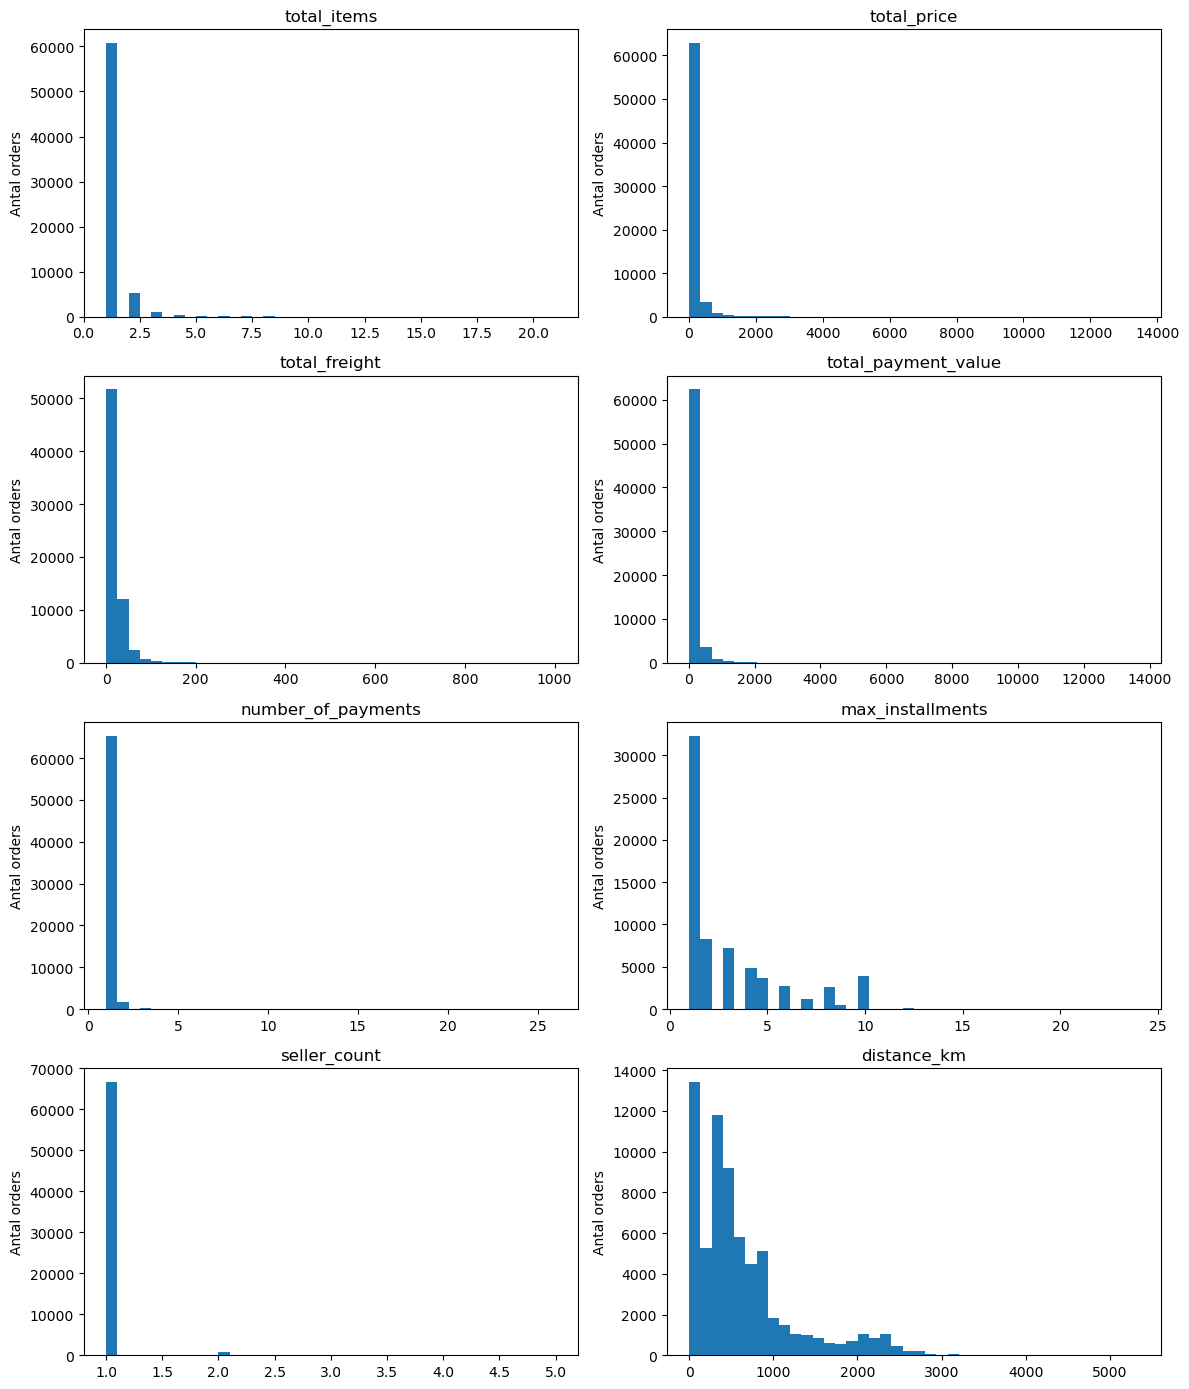

Saved: artifacts\eda_plots\numeric_distributions.png


In [97]:
# Rita fördelningar för numeriska variabler
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    ax.hist(
        train[column].dropna(),
        bins=40
    )
    ax.set_title(column)
    ax.set_xlabel("")
    ax.set_ylabel("Antal orders")

plt.tight_layout()

# Spara figuren som artifact
plot_path = plots_dir / "numeric_distributions.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

## Kategoriska variabler

De kategoriska variablerna undersöks med fokus på cardinality,
fördelning mellan kategorier och förekomst av sällsynta värden.

Vi kontrollerar även om kategorierna innehåller uppenbara problem som
extra blanksteg eller inkonsekvent användning av stora och små bokstäver.

Postnummerprefix analyseras separat eftersom de har hög cardinality och
fungerar som geografiska identifierare snarare än vanliga kategoriska
variabler.

In [98]:
# Sammanfatta kategoriska variabler
categorical_summary = []

for column in categorical_columns:
    counts = train[column].value_counts(dropna=False)

    categorical_summary.append({
        "feature": column,
        "unique_values": train[column].nunique(dropna=True),
        "most_common": counts.index[0],
        "most_common_count": counts.iloc[0],
        "rare_categories_under_1_percent": (
            counts < len(train) * 0.01
        ).sum()
    })

categorical_summary = pd.DataFrame(
    categorical_summary
).set_index("feature")

categorical_summary

,unique_values,most_common,most_common_count,rare_categories_under_1_percent
feature,,,,
order_status,2,delivered,67527,1
customer_state,27,SP,27204,14
seller_state,22,SP,47848,16


In [99]:
# Kontrollera kategorivärden och datakvalitet
for column in categorical_columns:
    print(f"\n--- {column} ---")
    
    print("Unika värden:")
    print(sorted(train[column].dropna().astype(str).unique()))
    
    messy_count = (
        train[column].dropna().astype(str)
        != train[column].dropna().astype(str).str.strip().str.upper()
    ).sum()
    
    print("Potentiellt inkonsekventa värden:", messy_count)


--- order_status ---
Unika värden:
['canceled', 'delivered']
Potentiellt inkonsekventa värden: 67533

--- customer_state ---
Unika värden:
['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']
Potentiellt inkonsekventa värden: 0

--- seller_state ---
Unika värden:
['AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RS', 'SC', 'SE', 'SP']
Potentiellt inkonsekventa värden: 0


### Tolkning av kategoriska variabler

`customer_state` och `seller_state` har konsekventa kategorivärden.
Samtliga state-koder använder samma format med två stora bokstäver och
inga uppenbara problem med extra blanksteg eller inkonsekvent stavning
identifierades.

Flera states förekommer i mindre än 1 % av träningsdata. Dessa betraktas
som sällsynta kategorier, men de behöver inte vara felaktiga eftersom
vissa geografiska områden naturligt har färre orders.

`order_status` innehåller endast `delivered` och `canceled`. Variabeln är
nästan konstant eftersom 67 527 av 67 533 orders är `delivered`.
Resultatet från den automatiska uppercase-kontrollen för `order_status`
tolkas inte som ett datakvalitetsproblem, eftersom statusvärdena är
konsekvent skrivna med små bokstäver.

På grund av den mycket låga variationen och eftersom orderstatus kan
förändras efter köptillfället är `order_status` inte en stark kandidat
som modellfeature.

In [100]:
# Undersök cardinality för geografiska identifierare
geographic_cardinality = pd.DataFrame({
    "unique_values": train[geographic_id_columns].nunique(),
    "unique_percent": (
        train[geographic_id_columns].nunique()
        / len(train) * 100
    ).round(2)
})

geographic_cardinality

,unique_values,unique_percent
customer_zip_code_prefix,13748,20.36
seller_zip_code_prefix,1681,2.49


### Tolkning av geografiska identifierare

Postnummerprefixerna har relativt hög cardinality.

`customer_zip_code_prefix` har 13 748 unika värden, vilket motsvarar
20,36 % av antalet orders i träningsdata. `seller_zip_code_prefix` har
1 681 unika värden.

Att one-hot-enkoda dessa råa postnummerprefix skulle kunna skapa ett
stort antal features och en mycket gles feature-matris.

Därför är de råa postnummerprefixerna inte förstahandsval som
modellfeatures. Geografisk information kan i stället representeras mer
kompakt med exempelvis `customer_state`, `seller_state` och
`distance_km`.

## Target och samband med `late`

Först undersöks fördelningen av target-variabeln `late` i träningsdata.

Eftersom problemet är en binär klassificering är det viktigt att förstå
class imbalance innan samband mellan features och target analyseras.

      count  percent
late                
0     61436    90.97
1      6097     9.03


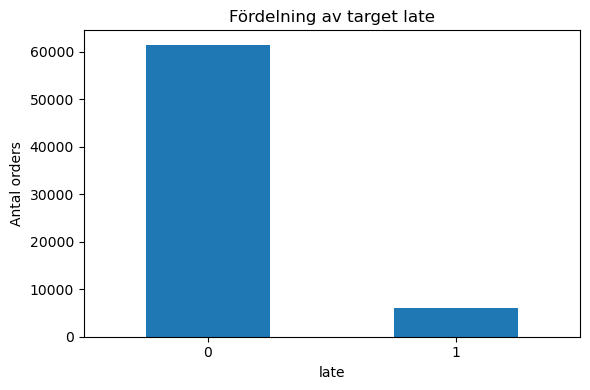

Saved: artifacts\eda_plots\target_distribution.png


In [101]:
# Undersök target-fördelningen
target_counts = train["late"].value_counts().sort_index()
target_percent = (
    train["late"].value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent
})

print(target_summary)

# Visualisera target-fördelningen
plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")

plt.title("Fördelning av target late")
plt.xlabel("late")
plt.ylabel("Antal orders")
plt.xticks(rotation=0)
plt.tight_layout()

plot_path = plots_dir / "target_distribution.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

### Tolkning av target-fördelningen

Target-variabeln är tydligt obalanserad.

I träningsdata har 61 436 orders (`90,97 %`) `late = 0`, medan
6 097 orders (`9,03 %`) har `late = 1`.

En modell som alltid förutsäger majoritetsklassen skulle därför kunna
uppnå hög accuracy utan att identifiera sena leveranser. Accuracy bör
därför inte användas som enda utvärderingsmått. Class imbalance behöver
beaktas vid modellering och utvärdering i senare notebooks.

In [102]:
# Jämför medianvärden för numeriska variabler mellan target-klasserna
numeric_by_target = (
    train
    .groupby("late")[numeric_columns]
    .median()
    .T
)

numeric_by_target.columns = [
    "median_late_0",
    "median_late_1"
]

numeric_by_target

,median_late_0,median_late_1
total_items,1.000000,1.000000
total_price,84.990000,89.990000
total_freight,16.600000,18.120000
total_payment_value,103.050000,113.855000
number_of_payments,1.000000,1.000000
max_installments,2.000000,2.000000
seller_count,1.000000,1.000000
distance_km,437.488578,553.044981


### Tolkning av numeriska samband med target

Jämförelsen visar vissa skillnader mellan sena och icke-sena orders.

Den tydligaste skillnaden syns för `distance_km`. Medianavståndet är cirka
437 km för orders med `late = 0` och cirka 553 km för orders med
`late = 1`. Längre transportavstånd kan därför vara relevant för att
förklara risken för sen leverans.

Även `total_price`, `total_freight` och `total_payment_value` har något
högre medianvärden bland sena orders.

För `total_items`, `number_of_payments`, `max_installments` och
`seller_count` är medianen lika mellan target-klasserna. Detta innebär
inte automatiskt att variablerna saknar prediktiv information, men
skillnaden syns inte tydligt genom medianen ensam.

In [103]:
# Beräkna korrelation mellan numeriska variabler och target
correlation_columns = numeric_columns + ["late"]

correlation_matrix = (
    train[correlation_columns]
    .corr()
    .round(3)
)

correlation_with_target = (
    correlation_matrix["late"]
    .drop("late")
    .sort_values(ascending=False)
)

correlation_with_target

distance_km            0.087
total_freight          0.047
total_payment_value    0.025
total_price            0.021
max_installments       0.017
number_of_payments    -0.006
total_items           -0.016
seller_count          -0.026
Name: late, dtype: float64

### Tolkning av korrelationer

De linjära korrelationerna mellan de numeriska variablerna och `late`
är generellt svaga.

`distance_km` har den högsta positiva korrelationen med target
(`0,087`), vilket stödjer observationen att sena orders tenderar att ha
något längre transportavstånd.

`total_freight`, `total_payment_value` och `total_price` har svaga
positiva korrelationer med `late`, medan övriga numeriska variabler
ligger nära noll.

En låg korrelation innebär inte automatiskt att en feature saknar
prediktivt värde. Samband kan vara icke-linjära eller uppstå genom
kombinationer av flera features.

## Tidsrelaterad analys

Tidsvariabler analyseras för att undersöka leveranstider, säsongsmönster
och variation mellan olika tidsperioder.

Både faktisk och uppskattad leveranstid kan studeras i EDA. Den faktiska
leveranstiden får däremot inte användas som modellfeature eftersom den
innehåller information som blir känd först efter leveransen.

In [104]:
# Skapa leveranstider för EDA
train["actual_delivery_days"] = (
    train["order_delivered_customer_date"]
    - train["order_purchase_timestamp"]
).dt.total_seconds() / 86400

train["estimated_delivery_days"] = (
    train["order_estimated_delivery_date"]
    - train["order_purchase_timestamp"]
).dt.total_seconds() / 86400

delivery_time_summary = train[
    ["actual_delivery_days", "estimated_delivery_days"]
].describe().T

delivery_time_summary

,count,mean,std,min,25%,50%,75%,max
actual_delivery_days,67533.0,13.824767,10.249351,0.533414,7.450845,11.475266,17.189977,209.628611
estimated_delivery_days,67533.0,24.597288,8.022133,7.005127,19.543333,23.621377,28.565984,155.135463


### Tolkning av leveranstider

Den faktiska leveranstiden har en median på cirka 11,5 dagar, medan den
uppskattade leveranstiden har en median på cirka 23,6 dagar.

Det finns även orders med betydligt längre leveranstider. Eftersom inga
negativa leveranstider identifieras betraktas dessa extrema observationer
inte automatiskt som datakvalitetsfel.

`actual_delivery_days` är användbar för EDA men får inte användas som
modellfeature, eftersom den bygger på det faktiska leveransdatumet och
därmed innehåller framtida information.

`estimated_delivery_days` bygger däremot på information som kan vara
tillgänglig vid ordertillfället och är därför en möjlig feature för
senare modellering.

In [105]:
# Undersök utvecklingen av sena leveranser över tid
train["purchase_month"] = (
    train["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_late = (
    train
    .groupby("purchase_month")
    .agg(
        orders=("order_id", "count"),
        late_rate=("late", "mean")
    )
    .reset_index()
)

monthly_late["late_rate_percent"] = (
    monthly_late["late_rate"] * 100
)

monthly_late

,purchase_month,orders,late_rate,late_rate_percent
0,2016-09,1,1.000000,100.000000
1,2016-10,270,0.011111,1.111111
2,2016-12,1,0.000000,0.000000
3,2017-01,750,0.030667,3.066667
4,2017-02,1653,0.032063,3.206292
5,2017-03,2546,0.055774,5.577376
6,2017-04,2303,0.078593,7.859314
7,2017-05,3545,0.036107,3.610719
8,2017-06,3135,0.038596,3.859649
9,2017-07,3872,0.034349,3.434917


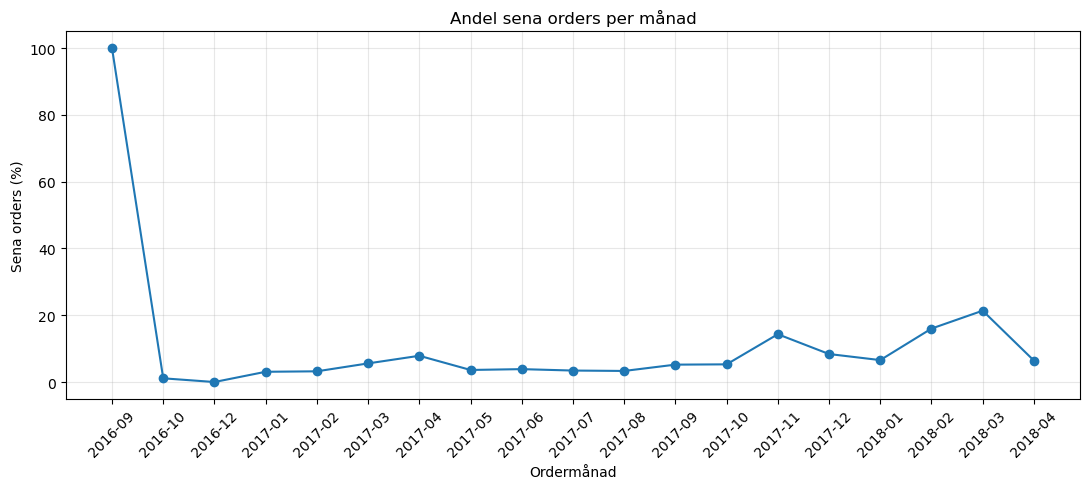

Saved: artifacts\eda_plots\monthly_late_rate.png


In [106]:
# Visualisera andelen sena orders över tid
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_late["purchase_month"],
    monthly_late["late_rate_percent"],
    marker="o"
)

plt.title("Andel sena orders per månad")
plt.xlabel("Ordermånad")
plt.ylabel("Sena orders (%)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

# Spara figuren som artifact
plot_path = plots_dir / "monthly_late_rate.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

### Tolkning av tidsmönster

Andelen sena orders varierar tydligt mellan olika månader, vilket visar
att leveransrisken förändras över tid.

Under stora delar av 2017 ligger andelen sena orders på relativt låga
nivåer, men den ökar tydligt i november 2017 och når högre nivåer under
februari och mars 2018.

De första månaderna i datasetet innehåller mycket få orders. Exempelvis
bygger 100 % sena orders i september 2016 på endast en order och bör
därför inte tolkas som ett stabilt säsongsmönster.

Resultatet tyder på att tidsinformation kan vara relevant för modellen.
Features som månad, veckodag och andra variabler som kan skapas från
`order_purchase_timestamp` bör därför undersökas vidare.

In [107]:
# Undersök andelen sena orders per veckodag
train["purchase_weekday"] = (
    train["order_purchase_timestamp"].dt.day_name()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_late = (
    train
    .groupby("purchase_weekday")
    .agg(
        orders=("order_id", "count"),
        late_rate=("late", "mean")
    )
    .reindex(weekday_order)
)

weekday_late["late_rate_percent"] = (
    weekday_late["late_rate"] * 100
).round(2)

weekday_late

,orders,late_rate,late_rate_percent
purchase_weekday,,,
Monday,10736,0.100224,10.02
Tuesday,10729,0.092646,9.26
Wednesday,10339,0.086082,8.61
Thursday,10005,0.082859,8.29
Friday,9885,0.094689,9.47
Saturday,7594,0.089676,8.97
Sunday,8245,0.083808,8.38


### Tolkning av veckodag

Andelen sena orders varierar något beroende på vilken veckodag ordern
skapades.

Måndag har den högsta andelen sena orders med cirka 10,02 %, medan
torsdag och söndag ligger lägst med cirka 8,29 % respektive 8,38 %.

Skillnaderna är relativt små, men de visar att veckodag kan innehålla
viss information om leveransrisken. Eftersom veckodagen kan skapas från
`order_purchase_timestamp` och är känd vid ordertillfället är den en
möjlig feature för senare modellering.

### Helgdagar

Helgdagar kan potentiellt påverka leveranstider. Datasetet innehåller
dock ingen verifierad kalender för brasilianska helgdagar.

Ingen holiday-feature skapas därför i denna EDA. Detta undviker att
introducera antaganden eller felaktigt klassificerade datum. En sådan
feature skulle kunna läggas till senare om en tillförlitlig extern
helgdagskalender används.

## Geografisk analys

Geografiska variabler undersöks för att bedöma om leveransrisk varierar
med transportavstånd eller geografiskt område.

Analysen fokuserar på `distance_km`, kundens state och säljarens state.
De råa postnummerprefixerna har redan identifierats som variabler med
hög cardinality.

In [108]:
# Dela in leveransavstånd i grupper och jämför med target
distance_analysis = train.copy()

distance_analysis["distance_group"] = pd.cut(
    distance_analysis["distance_km"],
    bins=[0, 250, 500, 1000, 2000, float("inf")],
    labels=[
        "0-250 km",
        "250-500 km",
        "500-1000 km",
        "1000-2000 km",
        "2000+ km"
    ],
    include_lowest=True
)

distance_late = (
    distance_analysis
    .groupby("distance_group", observed=False)
    .agg(
        orders=("order_id", "count"),
        late_rate=("late", "mean")
    )
)

distance_late["late_rate_percent"] = (
    distance_late["late_rate"] * 100
).round(2)

distance_late

,orders,late_rate,late_rate_percent
distance_group,,,
0-250 km,18015,0.053400,5.34
250-500 km,19527,0.091105,9.11
500-1000 km,18613,0.099608,9.96
1000-2000 km,7007,0.121307,12.13
2000+ km,4027,0.152471,15.25


### Tolkning av leveransavstånd

Det finns ett tydligt samband mellan leveransavstånd och risken för sen
leverans.

Andelen sena orders ökar från 5,34 % för avstånd upp till 250 km till
15,25 % för orders med ett avstånd över 2 000 km.

Mönstret stödjer den tidigare korrelationsanalysen och visar att
`distance_km` innehåller relevant information om leveransrisken.
Variabeln är därför en tydlig kandidat för feature engineering och
modellering.

In [109]:
# Jämför leveransrisk mellan kundens states
customer_state_late = (
    train
    .groupby("customer_state")
    .agg(
        orders=("order_id", "count"),
        late_rate=("late", "mean")
    )
)

customer_state_late["late_rate_percent"] = (
    customer_state_late["late_rate"] * 100
).round(2)

# Visa states med tillräckligt många orders för stabilare jämförelse
customer_state_late_filtered = (
    customer_state_late[
        customer_state_late["orders"] >= 500
    ]
    .sort_values("late_rate_percent", ascending=False)
)

customer_state_late_filtered

,orders,late_rate,late_rate_percent
customer_state,,,
MA,548,0.215328,21.53
CE,948,0.182489,18.25
RJ,8967,0.165830,16.58
BA,2307,0.149978,15.00
PA,718,0.133705,13.37
ES,1445,0.132872,13.29
SC,2577,0.119519,11.95
PE,1117,0.119069,11.91
MS,502,0.117530,11.75


### Tolkning av kundens geografiska område

Andelen sena orders varierar tydligt mellan olika `customer_state`.

Bland states med minst 500 orders har exempelvis MA, CE och RJ en
betydligt högre andel sena leveranser än SP och PR.

Analysen begränsades till states med minst 500 orders för att undvika
att dra starka slutsatser från mycket små grupper.

Resultatet visar ett geografiskt samband med target, men ska inte tolkas
som ett direkt orsakssamband. Skillnaderna kan även påverkas av exempelvis
transportavstånd och andra logistiska faktorer.

`customer_state` är därför en relevant kandidat som kategorisk feature.

In [114]:
# Crosstab mellan kundens state och target
customer_state_crosstab = pd.crosstab(
    train["customer_state"],
    train["late"],
    normalize="index"
) * 100

customer_state_crosstab.columns = ["not_late_percent", "late_percent"]

customer_state_crosstab.round(2)

,not_late_percent,late_percent
customer_state,,
AC,95.45,4.55
AL,72.15,27.85
AM,95.24,4.76
AP,94.12,5.88
BA,85.00,15.00
CE,81.75,18.25
DF,92.02,7.98
ES,86.71,13.29
GO,90.42,9.58


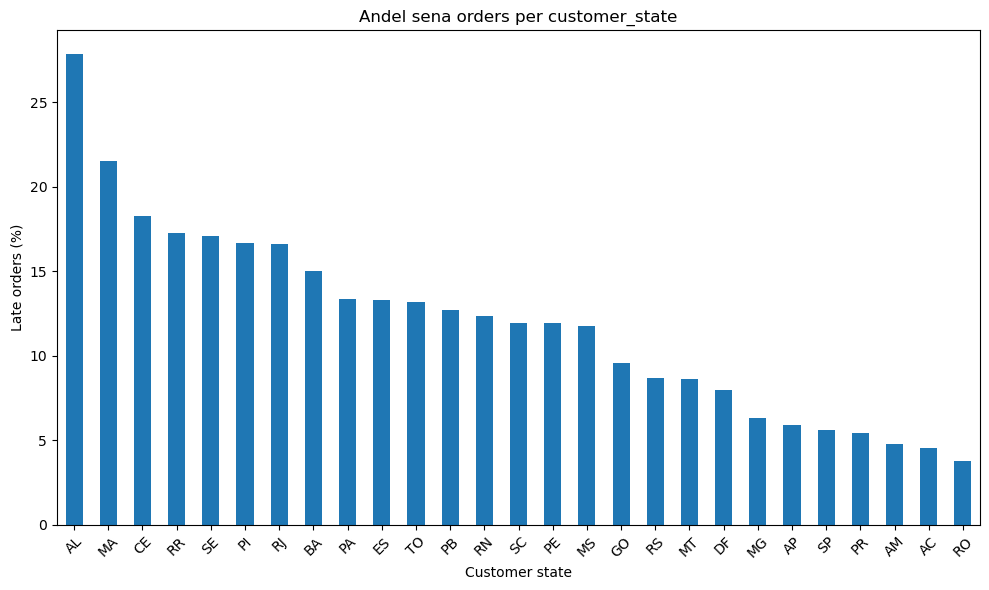

Plot saved: artifacts\eda_plots\customer_state_late_rate.png


In [115]:
# Rita andelen sena orders per customer_state
customer_state_plot = (
    customer_state_crosstab["late_percent"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
customer_state_plot.plot(kind="bar")

plt.title("Andel sena orders per customer_state")
plt.xlabel("Customer state")
plt.ylabel("Late orders (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plot_path = plots_dir / "customer_state_late_rate.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved:", plot_path)

### Tolkning av crosstab

Crosstabellen visar fördelningen mellan sena och icke sena orders inom
varje `customer_state`.

Resultatet bekräftar att andelen sena orders varierar tydligt mellan
olika geografiska områden. Exempelvis har MA, CE och RJ högre andel sena
orders än SP och PR.

Vissa states visar mycket höga eller låga procentandelar, men dessa
resultat måste tolkas tillsammans med antalet orders i respektive state.
Små grupper kan annars ge instabila procentsatser.

Crosstabellen stödjer därför den tidigare slutsatsen att
`customer_state` kan innehålla relevant prediktiv information.

In [110]:
# Jämför leveransrisk mellan säljarens states
seller_state_late = (
    train
    .groupby("seller_state")
    .agg(
        orders=("order_id", "count"),
        late_rate=("late", "mean")
    )
)

seller_state_late["late_rate_percent"] = (
    seller_state_late["late_rate"] * 100
).round(2)

# Visa states med minst 500 orders
seller_state_late_filtered = (
    seller_state_late[
        seller_state_late["orders"] >= 500
    ]
    .sort_values("late_rate_percent", ascending=False)
)

seller_state_late_filtered

,orders,late_rate,late_rate_percent
seller_state,,,
RJ,2693,0.098775,9.88
SP,47848,0.098040,9.80
PR,5370,0.076723,7.67
SC,2584,0.065402,6.54
DF,587,0.063032,6.30
MG,5636,0.062101,6.21
RS,1282,0.042902,4.29


### Tolkning av säljarens geografiska område

Andelen sena orders varierar även mellan olika `seller_state`, men
skillnaderna är mindre tydliga än för `customer_state`.

Bland states med minst 500 orders ligger exempelvis RJ och SP högre,
medan RS har en lägre andel sena orders.

Resultatet tyder på att säljarens geografiska område kan innehålla viss
prediktiv information. `seller_state` behålls därför som en möjlig
kategorisk feature, men sambandet ska inte tolkas som kausalt.

In [111]:
# Undersök om kund och säljare finns i samma state
train["same_state"] = (
    train["customer_state"] == train["seller_state"]
)

same_state_late = (
    train
    .groupby("same_state")
    .agg(
        orders=("order_id", "count"),
        late_rate=("late", "mean")
    )
)

same_state_late["late_rate_percent"] = (
    same_state_late["late_rate"] * 100
).round(2)

same_state_late

,orders,late_rate,late_rate_percent
same_state,,,
False,44453,0.108722,10.87
True,23080,0.054766,5.48


### Tolkning av samma state

Orders där kund och säljare finns i olika states har en tydligt högre
andel sena leveranser.

När kund och säljare finns i samma state är andelen sena orders cirka
5,48 %, jämfört med 10,87 % när de finns i olika states.

Resultatet stödjer den tidigare observationen att geografi och
transportavstånd är relevanta för leveransrisken.

`same_state` är därför en enkel och tolkningsbar kandidat för feature
engineering.

In [112]:
# Kontrollera om datasetet innehåller fritextkolumner
text_columns = []

print("Textkolumner:", text_columns)
print("Antal textkolumner:", len(text_columns))

Textkolumner: []
Antal textkolumner: 0


### Textvariabler

Träningsdata innehåller inga fritextkolumner. Ingen särskild
textpreprocessing eller textbaserad feature engineering behövs därför
i nästa steg.

## Beslut inför feature engineering

EDA:n visar vilka variabler som är relevanta att ta vidare och vilka som
bör exkluderas för att undvika data leakage eller onödigt hög
dimensionalitet.

### Kandidater för modellfeatures

Följande information bedöms som relevant och möjlig att använda:

- orderinformation: `total_items`, `total_price` och `total_freight`
- betalningsinformation: `total_payment_value`, `number_of_payments`
  och `max_installments`
- geografisk information: `customer_state`, `seller_state`,
  `seller_count` och `distance_km`
- en härledd feature `same_state` som anger om kund och säljare finns
  i samma state
- tidsfeatures från `order_purchase_timestamp`, exempelvis månad,
  veckodag och timme
- `estimated_delivery_days`, som beskriver den uppskattade tiden mellan
  orderdatum och beräknat leveransdatum

### Variabler som inte ska användas som modellfeatures

- `order_id` och `customer_id` är identifierare och saknar generell
  prediktiv betydelse.
- `customer_zip_code_prefix` och `seller_zip_code_prefix` har hög
  cardinality och ersätts av mer kompakta geografiska features.
- `order_delivered_customer_date`, `order_delivered_carrier_date` och
  `actual_delivery_days` innehåller information från framtiden och skulle
  orsaka target leakage.
- `order_approved_at` inträffar efter ordertillfället och exkluderas för
  att hålla prediction-scenariot konsekvent.
- `order_status` är nästan konstant i träningsdata och kan dessutom
  förändras efter att ordern skapats. Den exkluderas därför.
- råa datumkolumner används inte direkt när motsvarande relevanta
  tidsfeatures kan härledas.

### Preprocessing

Numeriska variabler innehåller viss skewness och extrema observationer,
men inga tydliga orimliga värden identifierades. Outliers tas därför inte
bort automatiskt.

Saknade numeriska värden är få och kan hanteras med imputering.
Kategoriska variabler behöver kodas numeriskt innan modellträning.

Alla preprocessing-transformeringar ska fit:as endast på träningsdata
och därefter appliceras oförändrade på validation- och testdata.

In [ ]:
# Spara en kort sammanfattning av de viktigaste EDA-resultaten
eda_summary = """
EDA-sammanfattning - träningsdata

- Analysen genomfördes endast på train.csv för att undvika data leakage.
- Träningsdata innehåller 67 533 orders och en rad per order.
- Target late är obalanserad: cirka 9,03 % av orders är sena.
- Saknade värden är få. distance_km har flest saknade värden, cirka 0,51 %.
- Numeriska variabler är generellt högerskeva och innehåller extrema värden,
  men inga tydligt orimliga negativa värden identifierades.
- distance_km visar ett tydligt samband med sena leveranser. Late rate ökar
  från 5,34 % för 0-250 km till 15,25 % för avstånd över 2 000 km.
- customer_state visar tydliga geografiska skillnader i leveransrisk.
- seller_state visar också variation, men sambandet är mindre tydligt.
- Orders där kund och säljare finns i olika states har cirka 10,87 % late rate,
  jämfört med 5,48 % när de finns i samma state.
- Leveransrisken varierar över tid, särskilt mellan olika månader.
- Veckodag visar mindre men observerbara skillnader i late rate.
- Råa zip-prefix har hög cardinality och bör inte one-hot-kodas direkt.
- Datasetet innehåller inga fritextkolumner.
- Framtida leveransdatum och andra post-order-variabler ska exkluderas från
  modellen för att undvika target leakage.
- Feature engineering bör fokusera på order-, betalnings-, tids- och
  geografiska variabler som är tillgängliga vid predictionstillfället.
"""

summary_path = artifacts_dir / "eda_summary.txt"
summary_path.write_text(eda_summary.strip(), encoding="utf-8")

print("EDA summary saved:", summary_path)

EDA summary saved: artifacts\eda_summary.txt


## SISTA RESULTAT


EDA:n genomfördes enbart på träningsdata för att undvika data leakage.

Analysen visar att target `late` är tydligt obalanserad, med cirka
9 % sena orders. Detta innebär att accuracy ensam inte är ett lämpligt
mått för den senare modellutvärderingen.

De numeriska variablerna är generellt högerskeva och innehåller extrema
observationer, men inga tydligt orimliga värden identifierades.
Saknade värden förekommer i liten omfattning och kan hanteras genom
preprocessing i nästa steg.

Geografi visade sig vara särskilt relevant. Risken för sen leverans ökar
med `distance_km`, och både kundens geografiska område och om kund och
säljare finns i samma state visar tydliga samband med target.

Även tidsanalysen visar variation mellan månader och mindre skillnader
mellan veckodagar. Detta motiverar att skapa tidsbaserade features från
`order_purchase_timestamp`.

EDA:n identifierade samtidigt flera variabler som inte ska användas för
modellering. Identifierare och högkardinala postnummerprefix bör
exkluderas, medan information som uppstår efter ordertillfället inte får
användas eftersom den skulle orsaka target leakage.

Resultaten från denna notebook används som grund för feature engineering
och preprocessing i nästa steg. En kort sammanfattning har även sparats
som `artifacts/eda_summary.txt`.